In [104]:
from tool.utils.image_tool import find_image_by_name
from tool.utils.minimap_util import rotate_minimap, mask_minimap_center
from copy import deepcopy
import numpy as np
import cv2 as cv
def get_minimap(image, rotation=False, center_radius=80):
    """
    裁剪图像中的小地图区域

    Args:
        image (np.ndarray): 输入图像
        radius (int): 裁剪半径
        copy (bool): 是否复制图像
        rotation (bool): 是否进行旋转校正
        center_radius (int): 中心掩膜半径

    Returns:
        np.ndarray: 处理后的小地图图像
    """
    # 通过模板匹配获取准确的MINIMAP_CENTER（很奇怪，小地图相对坐标会变化）
    image = image.copy()
    if rotation:
        from tool.utils.mminimap import update_rotation
        # 获取输入图片的视角角度
        input_rotation = update_rotation(minimap=image)
        # 读取0度视角纹理图
        zero_texture = find_image_by_name("only_rotated.png")

        # 根据输入图片的视角旋转0度视角纹理图
        rotated_texture = rotate_minimap(zero_texture, input_rotation)
        # 从纹理中心裁剪以匹配目标图像尺寸
        if rotated_texture.shape != image.shape:
            tex_h, tex_w = rotated_texture.shape[:2]
            target_h, target_w = image.shape[:2]
            center_y, center_x = tex_h // 2, tex_w // 2
            half_target_h, half_target_w = target_h // 2, target_w // 2

            # 计算裁剪边界
            y1 = max(0, center_y - half_target_h)
            y2 = min(tex_h, center_y + half_target_h + (target_h % 2))
            x1 = max(0, center_x - half_target_w)
            x2 = min(tex_w, center_x + half_target_w + (target_w % 2))

            rotated_texture = rotated_texture[y1:y2, x1:x2]
        image = cv.subtract(image, rotated_texture)

        # 掩膜掩盖非中心区域避免遇敌红色圈干扰敌人追踪
        image = mask_minimap_center(image, center_radius=center_radius)
    return image

2026-04-05 19:06:22,370 - INFO - 发现 954 个记忆图像切片，正在载入缓冲区...
INFO:my customize logger:发现 954 个记忆图像切片，正在载入缓冲区...
2026-04-05 19:06:22,646 - INFO - 图像记忆切片载入完成: 954/954 成功
INFO:my customize logger:图像记忆切片载入完成: 954/954 成功
251
<xml><var name="_dummy_ipython_val"  />
<var name="_dummy_special_var"  />
<var name="MINIMAP_RADIUS" type="int" qualifier="builtins" value="93" />
<var name="bw_map" type="ndarray" qualifier="numpy" value="%5B%5B0 0 0 ... 0 0 0%5D%2C %5B0 0 0 ... 0 0 0%5D%2C %5B0 0 0 ... 0 0 0%5D%2C ...%2C %5B0 0 0 ... 0 0 0%5D%2C %5B0 0 0 ... 0 0 0%5D%2C %5B0 0 0 ... 0 0 0%5D%5D" isContainer="True" shape="(186, 186)" arrayElementType="uint8" />
<var name="grey_map" type="ndarray" qualifier="numpy" value="%5B%5B0 0 0 ... 0 0 0%5D%2C %5B0 0 0 ... 0 0 0%5D%2C %5B0 0 0 ... 0 0 0%5D%2C ...%2C %5B0 0 0 ... 0 0 0%5D%2C %5B0 0 0 ... 0 0 0%5D%2C %5B0 0 0 ... 0 0 0%5D%5D" isContainer="True" shape="(186, 186)" arrayElementType="uint8" />
<var name="image" type="ndarray" qualifier="numpy" value="%5

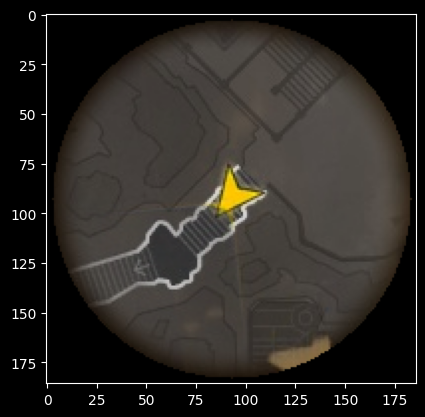

In [105]:
from importing import load_img
from matplotlib import pyplot as plt
load_img()
image=cv.imread("init2.jpg")
local_screen = get_minimap(image,rotation=True, center_radius=90)
plt.imshow(local_screen)
plt.show()

In [106]:
# local_screen = local_screen - cv.bitwise_and(local_screen, local_screen,mask=cv.inRange(cv.cvtColor(local_screen, cv.COLOR_BGR2HSV),np.array([80, 0, 0]), np.array([100, 255, 255])))
# plt.imshow(local_screen)
# plt.show()

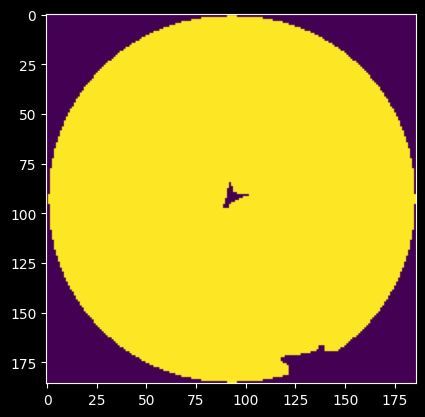

In [107]:

bw_map = np.zeros(local_screen.shape[:2], dtype=np.uint8)
grey_map = deepcopy(bw_map)
grey_map[np.sum((local_screen - np.array([55, 55, 55])) ** 2, axis=-1) <= 4800] = 255
grey_map = cv.dilate(grey_map, np.ones((5, 5), np.uint8), iterations=1)
plt.imshow(grey_map)
plt.show()

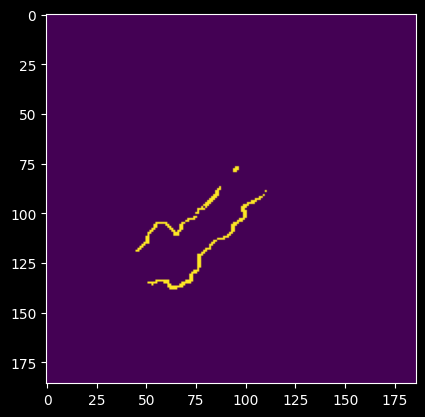

In [108]:

bw_map[(np.sum((local_screen - np.array([210, 210, 210])) ** 2, axis=-1) <= 9000) & (grey_map > 200)] = 255
plt.imshow(bw_map)
plt.show()
non_black_pixels = np.count_nonzero(bw_map)

In [109]:

print(non_black_pixels)